## ARBOLES DE DECISION


In [3]:
#Importamos las librerias 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [7]:
#CARGAMOS LOS DATOS 

data = pd.read_csv("Vino.csv")

# 1. Análisis Exploratorio de Datos python

In [11]:
#MOSTRAMOS LOS DATOS Y LAS PRIMERAS 10 FILAS 
data.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [13]:
#IDENTIFICAMOS LA CANTIDAD DE LOS DATOS, EN CUESTION DE FILAS Y COLUMNAS 
data.shape

(1599, 12)

In [19]:
#NOMBRES ORIGINALES DE LAS COLUMNAS 
print("Nombres originales de las columnas:")
print(data.columns)

Nombres originales de las columnas:
Index(['Acidez_Fija', 'Acidez_Volátil', 'Acidez_Cítrica', 'Azúcar_Residual',
       'Cloruros', 'Dióxido_Sulfuro_Libre', 'Dióxido_Sulfuro_Total',
       'Densidad', 'pH', 'Sulfatos', 'Alcohol', 'Calidad'],
      dtype='object')


In [17]:

# CAMBIAMOS LOS NOMBRES DE LAS COLUMNAS, PARA MAYOR FACILIDAD DE ENTENDIMIENTO
data.rename(columns={
    'fixed acidity': 'Acidez_Fija',
    'volatile acidity': 'Acidez_Volátil',
    'citric acid': 'Acidez_Cítrica',
    'residual sugar': 'Azúcar_Residual',
    'chlorides': 'Cloruros',
    'free sulfur dioxide': 'Dióxido_Sulfuro_Libre',
    'total sulfur dioxide': 'Dióxido_Sulfuro_Total',
    'density': 'Densidad',
    'pH': 'pH',
    'sulphates': 'Sulfatos',
    'alcohol': 'Alcohol',
    'quality': 'Calidad'
}, inplace=True)

# MOSTRAR LOS NUEVOS NOMBRES DE LAS COLUMNAS
print("\nNuevos nombres de las columnas:")
print(data.columns)


Nuevos nombres de las columnas:
Index(['Acidez_Fija', 'Acidez_Volátil', 'Acidez_Cítrica', 'Azúcar_Residual',
       'Cloruros', 'Dióxido_Sulfuro_Libre', 'Dióxido_Sulfuro_Total',
       'Densidad', 'pH', 'Sulfatos', 'Alcohol', 'Calidad'],
      dtype='object')


In [33]:
# Nuevos Nombres de las Columnas:
# Acidez_Fija: Representa la acidez fija del vino.
# Acidez_Volátil: Indica la cantidad de ácido acético en el vino.
# Acidez_Cítrica: Mide la cantidad de ácido cítrico en el vino.
# Azúcar_Residual: Cantidad de azúcar que queda en el vino después de la fermentación.
# Cloruros: Medida de la salinidad del vino.
# Dióxido_Sulfuro_Libre: Cantidad de dióxido de azufre libre en el vino.
# Dióxido_Sulfuro_Total: Total de dióxido de azufre en el vino.
# Densidad: Densidad del vino.
# pH: Medida de la acidez del vino.
# Sulfatos: Medida de los sulfatos en el vino.
# Alcohol: Porcentaje de alcohol en el vino.
# Calidad: Representa la calidad del vino.

In [23]:
#MOSTRAMOS LOS DATOS Y LAS PRIMERAS 10 FILAS (NUEVOS NOMBRES)
data.head(10)

,Acidez_Fija,Acidez_Volátil,Acidez_Cítrica,Azúcar_Residual,Cloruros,Dióxido_Sulfuro_Libre,Dióxido_Sulfuro_Total,Densidad,pH,Sulfatos,Alcohol,Calidad
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [25]:
#IDENTIFICAMOS LOS DATOS ESTADISTICOS
data.describe()

,Acidez_Fija,Acidez_Volátil,Acidez_Cítrica,Azúcar_Residual,Cloruros,Dióxido_Sulfuro_Libre,Dióxido_Sulfuro_Total,Densidad,pH,Sulfatos,Alcohol,Calidad
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [27]:
#IDENTIFICAMOS SI HAY DATOS FALTANTES 
data.isna().sum()

Acidez_Fija              0
Acidez_Volátil           0
Acidez_Cítrica           0
Azúcar_Residual          0
Cloruros                 0
Dióxido_Sulfuro_Libre    0
Dióxido_Sulfuro_Total    0
Densidad                 0
pH                       0
Sulfatos                 0
Alcohol                  0
Calidad                  0
dtype: int64

# 2. Procesamiento de Datos

In [35]:
# IDENTIFICAR LOS TIPOS DE VINO EN LA COLUMNA "CALIDAD"
tipos_de_vino = data['Calidad'].unique()
numero_de_tipos = len(tipos_de_vino)

# MMSOTRAR LOS TIPOS DE VINO Y SU CALIDAD
print(f'Número de tipos de vino en el dataset: {numero_de_tipos}')
print('Tipos de vino (calidad):', tipos_de_vino)

Número de tipos de vino en el dataset: 6
Tipos de vino (calidad): [5 6 7 4 8 3]


In [39]:
# Clasificación de la calidad del vino
print("Clasificación de la calidad del vino:")
print("3: Vino de baja calidad")
print("4: Vino de calidad inferior")
print("5: Vino de calidad media")
print("6: Vino de buena calidad")
print("7: Vino de calidad superior")
print("8: Vino de alta calidad")

Clasificación de la calidad del vino:
3: Vino de baja calidad
4: Vino de calidad inferior
5: Vino de calidad media
6: Vino de buena calidad
7: Vino de calidad superior
8: Vino de alta calidad


# Histograma del Alcohol en el Vino 

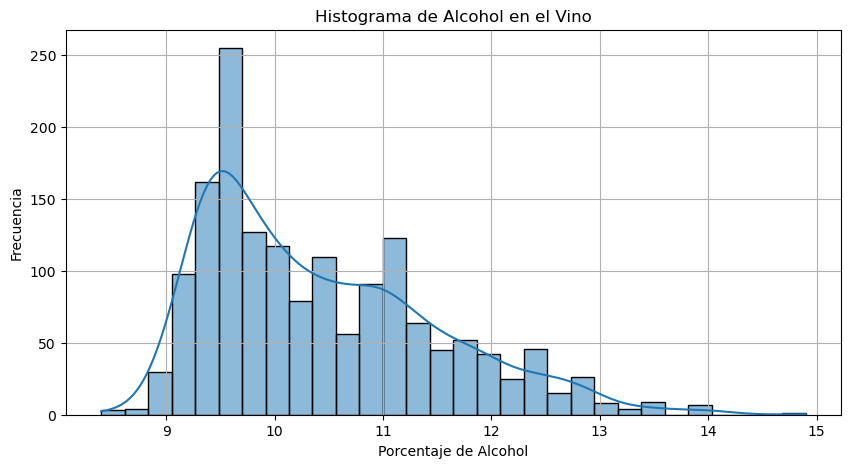

In [49]:
# Histograma de la variable 'Alcohol'
plt.figure(figsize=(10, 5))
sns.histplot(data['Alcohol'], bins=30, kde=True)
plt.title('Histograma de Alcohol en el Vino')
plt.xlabel('Porcentaje de Alcohol')
plt.ylabel('Frecuencia')
plt.grid()
plt.show()

# Box Plot de Alcohol por Calidad del Vino

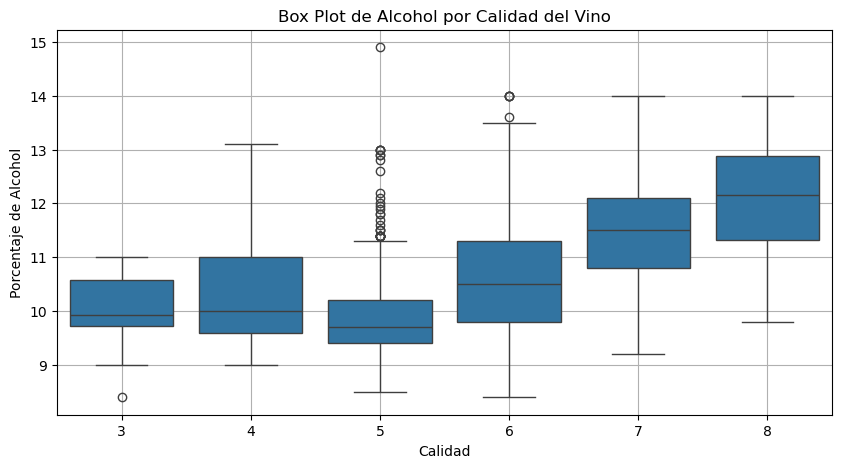

In [51]:
# Box Plot de la variable 'Calidad'
plt.figure(figsize=(10, 5))
sns.boxplot(x='Calidad', y='Alcohol', data=data)
plt.title('Box Plot de Alcohol por Calidad del Vino')
plt.xlabel('Calidad')
plt.ylabel('Porcentaje de Alcohol')
plt.grid()
plt.show()

# Identificacion de Datos Atipicos 

Outliers identificados en la variable 'Alcohol':
      Acidez_Fija  Acidez_Volátil  Acidez_Cítrica  Azúcar_Residual  Cloruros  \
142           5.2            0.34            0.00              1.8     0.050   
144           5.2            0.34            0.00              1.8     0.050   
467           8.8            0.46            0.45              2.6     0.065   
588           5.0            0.42            0.24              2.0     0.060   
652          15.9            0.36            0.65              7.5     0.096   
821           4.9            0.42            0.00              2.1     0.048   
1114          5.0            0.40            0.50              4.3     0.046   
1132          7.4            0.36            0.34              1.8     0.075   
1228          5.1            0.42            0.00              1.8     0.044   
1269          5.5            0.49            0.03              1.8     0.044   
1270          5.0            0.38            0.01              1.6     

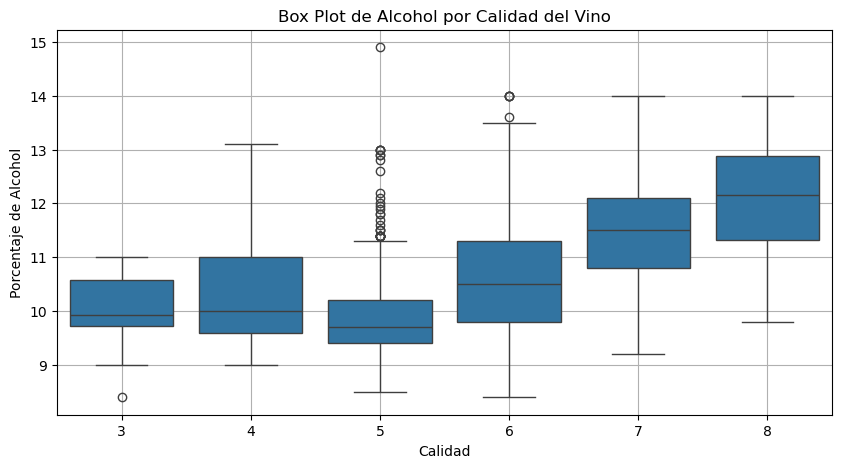

In [61]:
# Calcular los límites para identificar outliers
Q1 = data['Alcohol'].quantile(0.25)  # Primer cuartil
Q3 = data['Alcohol'].quantile(0.75)  # Tercer cuartil
IQR = Q3 - Q1                        # Rango intercuartílico

# Definir límites para outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar outliers
outliers = data[(data['Alcohol'] < limite_inferior) | (data['Alcohol'] > limite_superior)]

# Mostrar los outliers
print("Outliers identificados en la variable 'Alcohol':")
print(outliers)

# Visualizar el box plot con outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x='Calidad', y='Alcohol', data=data)
plt.title('Box Plot de Alcohol por Calidad del Vino')
plt.xlabel('Calidad')
plt.ylabel('Porcentaje de Alcohol')
plt.grid()
plt.show()


Basicamente no hay una gran cantidad de valores atipicos, ya que los outliers que se idenfican estan en las categoria 6 y 7, lo que significan que son de buena calidad, por ende no se consideran datos atipicos

Sin embargo, hay un caso (ID 652) con un contenido de alcohol de 15.9 y una calidad de 5, lo que podría indicar un vino que no cumple con las expectativas de calidad a pesar de su alto contenido de alcohol. En conclusion hay que eliminar los valores atipicos del alcohol en la categoria 5 

# Identificamos los valores atipicos de la categoria 5 

In [77]:
# Filtrar los datos de calidad 5
data_calidad_5 = data[data['Calidad'] == 5]

# Calcular los límites para identificar outliers en la variable 'Alcohol'
Q1 = data_calidad_5['Alcohol'].quantile(0.25)
Q3 = data_calidad_5['Alcohol'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites para outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar outliers en calidad 5
outliers_calidad_5 = data_calidad_5[(data_calidad_5['Alcohol'] < limite_inferior) | (data_calidad_5['Alcohol'] > limite_superior)]

# Mostrar los outliers identificados
print("Outliers identificados en la calidad 5:")
print(outliers_calidad_5)




Outliers identificados en la calidad 5:
      Acidez_Fija  Acidez_Volátil  Acidez_Cítrica  Azúcar_Residual  Cloruros  \
131           5.6           0.500            0.09             2.30     0.049   
132           5.6           0.500            0.09             2.30     0.049   
327          10.3           0.440            0.50             4.50     0.107   
353          13.5           0.530            0.79             4.80     0.120   
462          11.0           0.260            0.68             2.55     0.085   
553           5.0           1.040            0.24             1.60     0.050   
560          12.7           0.600            0.49             2.80     0.075   
565          12.7           0.600            0.49             2.80     0.075   
652          15.9           0.360            0.65             7.50     0.096   
731           8.9           0.875            0.13             3.45     0.088   
900           8.9           0.310            0.36             2.60     0.056   


# Corregimos los valores atipicos 

In [84]:
# Corregir los outliers
# Estrategia de corrección: reemplazar los outliers por el valor medio de la calidad 5
mean_alcohol = data_calidad_5['Alcohol'].mean()

# Reemplazar los outliers con el valor medio
data.loc[(data['Calidad'] == 5) & ((data['Alcohol'] < limite_inferior) | (data['Alcohol'] > limite_superior)), 'Alcohol'] = mean_alcohol


In [86]:
# Verificar la corrección
print("\nDatos corregidos en la calidad 5:")
print(data[data['Calidad'] == 5])


Datos corregidos en la calidad 5:
      Acidez_Fija  Acidez_Volátil  Acidez_Cítrica  Azúcar_Residual  Cloruros  \
0             7.4           0.700            0.00              1.9     0.076   
1             7.8           0.880            0.00              2.6     0.098   
2             7.8           0.760            0.04              2.3     0.092   
4             7.4           0.700            0.00              1.9     0.076   
5             7.4           0.660            0.00              1.8     0.075   
...           ...             ...             ...              ...       ...   
1582          6.1           0.715            0.10              2.6     0.053   
1583          6.2           0.460            0.29              2.1     0.074   
1589          6.6           0.725            0.20              7.8     0.073   
1594          6.2           0.600            0.08              2.0     0.090   
1597          5.9           0.645            0.12              2.0     0.075   

    

# Aqui podemos ver la correccion de los valores atipicos en el Box Plot

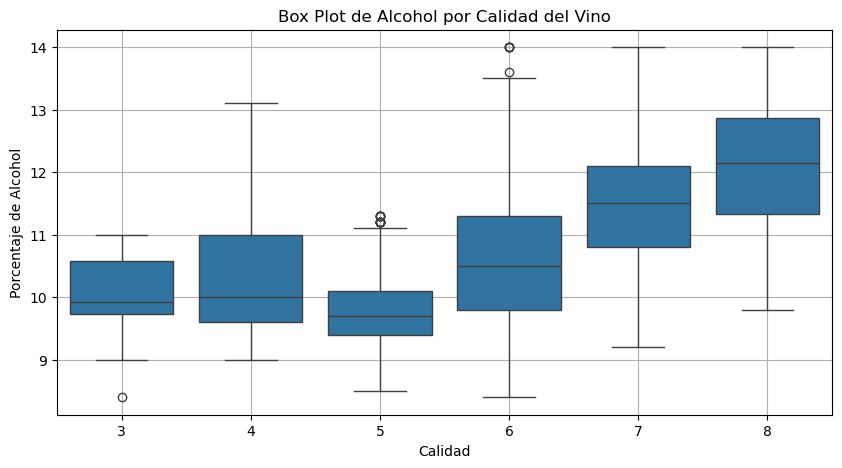

In [88]:
# Box Plot de la variable 'Calidad'
plt.figure(figsize=(10, 5))
sns.boxplot(x='Calidad', y='Alcohol', data=data)
plt.title('Box Plot de Alcohol por Calidad del Vino')
plt.xlabel('Calidad')
plt.ylabel('Porcentaje de Alcohol')
plt.grid()
plt.show()

In [108]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree

# Creamos el modelo de arbol de Decision

# Aqui realizamos 3 pasos en uno. Sellecionamos las caracteristicas, dividimos el dataset en train y test, evaluamos el modelo de arbol de decision, realizamos las predicciones y evaluamos el modelo y por ultimo calculamos el desempeño con las metricas de precision, recall, f1, etc..

Matriz de Confusión:
[[ 0  0  0  1  0  0]
 [ 1  0  4  5  0  0]
 [ 1  4 87 35  3  0]
 [ 0  8 30 73 20  1]
 [ 0  0  4 15 22  1]
 [ 0  0  1  1  2  1]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.69      0.67      0.68       130
           6       0.56      0.55      0.56       132
           7       0.47      0.52      0.49        42
           8       0.33      0.20      0.25         5

    accuracy                           0.57       320
   macro avg       0.34      0.32      0.33       320
weighted avg       0.58      0.57      0.57       320

Precisión: 0.5788
Recall: 0.5719
F1-Score: 0.5748
Exactitud: 0.5719


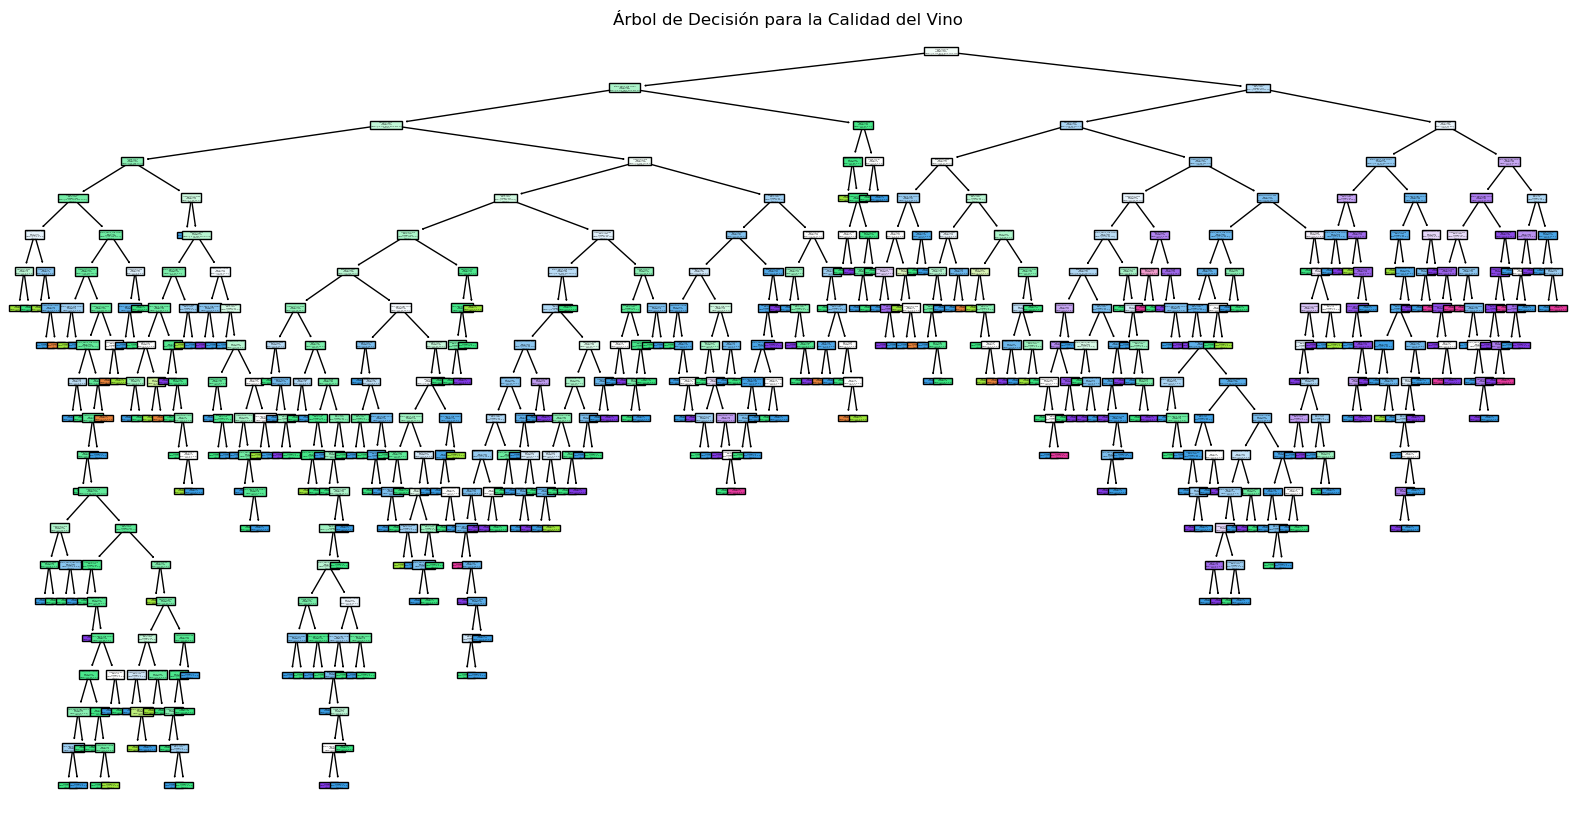

In [149]:
# Selecionamos las caracteristicas para la variable objetivo (utilizaremos todas la variables)
X = data[['Acidez_Fija', 'Acidez_Volátil', 'Acidez_Cítrica', 'Azúcar_Residual', 
           'Cloruros', 'Dióxido_Sulfuro_Libre', 'Dióxido_Sulfuro_Total', 
           'Densidad', 'pH', 'Sulfatos', 'Alcohol']]
y = data['Calidad']

# Dividimos el dataset en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creamos el modelo de arbol de Decision
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Realizar predicciones
y_pred = model.predict(X_test)

# Evaluamos el modelo
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Calculamos las metricas de desempeño (precision, recall, f1,etc..)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Mostrar métricas
print(f"Precisión: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Exactitud: {accuracy:.4f}")

# Visualizar el árbol de decisión
plt.figure(figsize=(20,10))
tree.plot_tree(model, feature_names=X.columns, class_names=[str(i) for i in sorted(y.unique())], filled=True)
plt.title('Árbol de Decisión para la Calidad del Vino')
plt.show()

# Matriz de correlacion

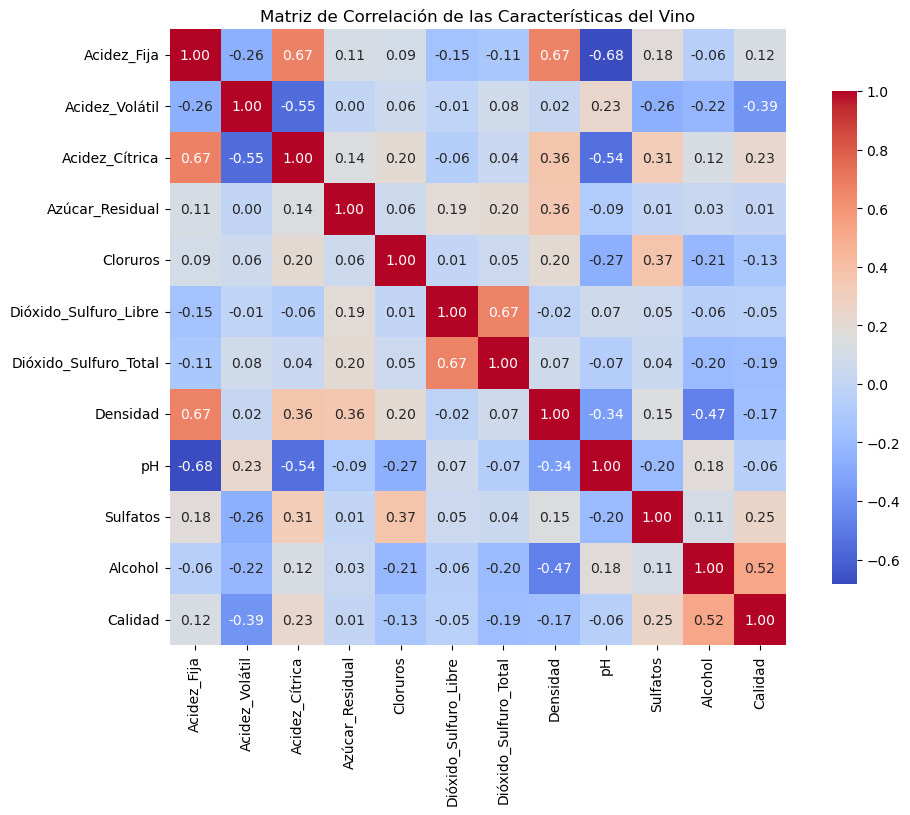

In [153]:
# Calculamos la matriz de correlación
corr = data.corr()

# Creamos un mapa de calor para visualizar la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación de las Características del Vino')
plt.show()

# Análisis de la Matriz de Correlación

La matriz de correlación muestra cómo se relacionan las diferentes características del vino con la variable objetivo, que en este caso es la calidad del vino: 

Variables y sus Correlaciones con la Calidad
    Alcohol:

    Correlación positiva alta (aproximadamente 0.48) con la calidad. Esto sugiere que a medida que aumenta el contenido de alcohol en el vino, también      tiende a aumentar la calidad. Esto puede ser indicativo de que los vinos con mayor contenido de alcohol son percibidos como de mejor calidad.
    
    Acidez Fija:

    Correlación negativa moderada (aproximadamente -0.17) con la calidad. Esto indica que un aumento en la acidez fija puede estar asociado con una         disminución en la calidad del vino. Esto puede ser relevante, ya que una acidez demasiado alta puede afectar negativamente el sabor del vino.
    
    Acidez Volátil:

    Correlación negativa moderada (aproximadamente -0.36) con la calidad. Esto sugiere que un aumento en la acidez volátil puede estar relacionado con      una menor calidad del vino. La acidez volátil se asocia a menudo con defectos en el vino, como el sabor a vinagre.
    
    Sulfatos:

    Correlación positiva moderada (aproximadamente 0.36) con la calidad. Esto sugiere que un mayor contenido de sulfatos puede estar asociado con una       mejor calidad del vino. Los sulfatos pueden influir en la percepción del sabor y la estabilidad del vino.
    
    Densidad:

    Correlación negativa (aproximadamente -0.2) con la calidad. Esto indica que a medida que la densidad del vino aumenta, la calidad tiende a              disminuir. Esto puede estar relacionado con el contenido de azúcar y otros componentes en el vino.
    
Otras Variables

    Azúcar Residual:

    La correlación con la calidad es baja, lo que sugiere que el contenido de azúcar residual no tiene un impacto significativo en la calidad del vino      en este conjunto de datos.
    
    pH:

    La correlación con la calidad es también baja, lo que indica que el pH no es un factor determinante en la calidad del vino.

#  Interpretación de Resultados del Modelo de Árbol de Decisión

Métricas de Desempeño

Precisión:

Un valor de precisión de 0.5788 indica que el modelo tiene un desempeño moderado en la identificación de las clases correctas. Esto significa que aproximadamente el 57.88% de las predicciones positivas son verdaderas.
Recall:

Un valor de recall de 0.5719 indica que el modelo es moderadamente efectivo en identificar todos los casos positivos. Esto es importante en contextos donde es crítico no perder instancias de una clase específica.

F1-Score:

Un F1-score de 0.5748 sugiere que el modelo tiene un desempeño moderado en equilibrar la precisión y el recall. Esto es especialmente útil en situaciones donde hay un desbalance entre las clases.

Exactitud:

Un valor de exactitud de 0.5719 indica que el modelo clasifica correctamente aproximadamente el 57.19% de las instancias en el conjunto de prueba.